# EDA: Análisis de Distribución de Papers por Planetary Boundaries

Este notebook analiza la distribución de papers en el corpus UPV-EARTH por:
- Planetary Boundaries (PB1-PB9)
- Sustainable Development Goals (SDG)
- Diferentes muestras del corpus

In [1]:
import pandas as pd
import numpy as np
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Corpus Limpio y Enriquecido (corpus completo)

In [ ]:
# Cargar el corpus limpio y enriquecido
master = pd.read_csv('../../data/corpus/master_corpus_mixto_clean_enriched.csv')

print('=== CORPUS LIMPIO Y ENRIQUECIDO ===')
print(f'Total de papers: {len(master)}')
print(f'Rango de años: {master["year"].min():.0f} - {master["year"].max():.0f}')
print(f'Papers con año válido: {master["year"].notna().sum()}')
print(f'\nColumnas: {list(master.columns)}')

=== CORPUS LIMPIO Y ENRIQUECIDO ===
Total de papers: 700
Rango de años: 1900 - 2075
Papers con año válido: 691

Columnas: ['doc_id', 'title', 'abstract_raw', 'abstract_norm', 'clean_abstract_lex', 'abstract', 'clean_abstract', 'year', 'doi', 'source', 'authors', 'keywords', 'journal', 'language', 'top_terms_no_stopwords', 'abstract_norm_len']



=== DISTRIBUCIÓN POR AÑO (últimos 15 años) ===
year
2075.0     1
2050.0     2
2044.0     1
2036.0     1
2030.0     2
2024.0    16
2023.0    35
2022.0    32
2021.0    48
2020.0    48
2019.0    41
2018.0    44
2017.0    40
2016.0    36
2015.0    38
Name: count, dtype: int64


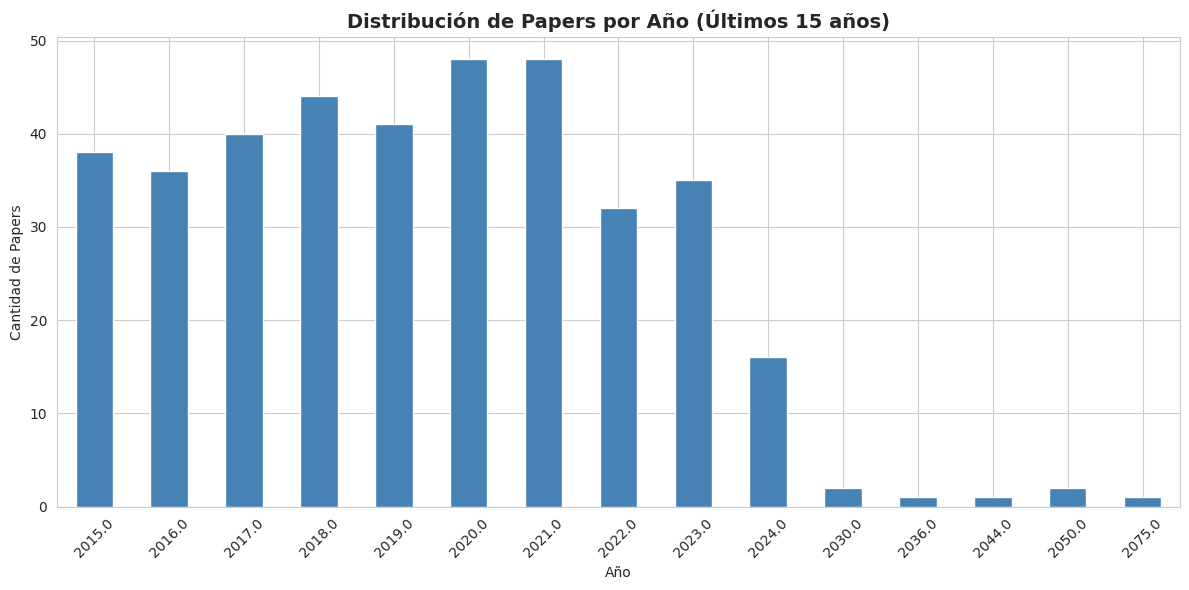

In [4]:
# Distribución por año (últimos 15 años)
year_dist = master['year'].value_counts().sort_index(ascending=False)

print('\n=== DISTRIBUCIÓN POR AÑO (últimos 15 años) ===')
print(year_dist.head(15))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
year_dist.head(15).sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribución de Papers por Año (Últimos 15 años)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de Papers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Listado Completo de PDFs (45,622 papers)

In [5]:
# Leer el archivo de listado completo
with open('../../muestras/listado_pdfs.txt', 'r', encoding='utf-8') as f:
    lines = [l.strip() for l in f.readlines() if l.strip()]

print(f'Total de líneas en archivo: {len(lines):,}')

# Contar papers por PB
pb_count_full = defaultdict(lambda: {'name': '', 'count': 0})

for line in lines:
    match = re.match(r'^(\d+)\s*-\s*(.+?)/(?:SDG|No SDG)', line)
    if match:
        pb_num = int(match.group(1))
        pb_name = match.group(2).strip()
        pb_count_full[pb_num]['name'] = pb_name
        pb_count_full[pb_num]['count'] += 1

print(f'\nTotal de papers contabilizados: {sum(info["count"] for info in pb_count_full.values()):,}')
print(f'Cantidad de PB representados: {len(pb_count_full)}')

Total de líneas en archivo: 45,622

Total de papers contabilizados: 45,622
Cantidad de PB representados: 9


In [6]:
# Crear DataFrame con distribución completa
pb_full_data = []
for pb_num in sorted(pb_count_full.keys()):
    info = pb_count_full[pb_num]
    pb_full_data.append({
        'PB': f'PB{pb_num}',
        'Nombre': info['name'],
        'Papers': info['count'],
        'Porcentaje': (info['count'] / len(lines)) * 100
    })

df_pb_full = pd.DataFrame(pb_full_data)

print('\n=== DISTRIBUCIÓN COMPLETA DE PAPERS POR PB ===')
print(df_pb_full.to_string(index=False))
print(f'\nTOTAL: {df_pb_full["Papers"].sum():,} papers')


=== DISTRIBUCIÓN COMPLETA DE PAPERS POR PB ===
 PB                        Nombre  Papers  Porcentaje
PB1                Climate Change   12229   26.805050
PB2           Ocean Acidification    4560    9.995178
PB3 Stratospheric Ozone Depletion    3681    8.068476
PB4          Biogeochemical Flows    3907    8.563851
PB5         Global Freshwater Use    3371    7.388979
PB6            Land System Change    5501   12.057779
PB7           Biosphere Integrity    3644    7.987375
PB8                Novel Entities    5465   11.978870
PB9   Atmospheric Aerosol Loading    3264    7.154443

TOTAL: 45,622 papers


In [ ]:
# Gráfico de distribución por PB (listado completo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
df_pb_full.sort_values('Papers', ascending=True).plot(
    x='PB', y='Papers', kind='barh', ax=ax1, color='coral', legend=False
)
ax1.set_title('Papers por Planetary Boundary (45,622 total)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cantidad de Papers')
ax1.set_ylabel('')

# Gráfico de pastel
colors = plt.cm.Set3(np.linspace(0, 1, len(df_pb_full)))
ax2.pie(df_pb_full['Papers'], labels=df_pb_full['PB'], autopct='%1.1f%%', colors=colors)
ax2.set_title('Distribución Porcentual de Papers', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Muestra Seleccionada (1,000 papers)

In [ ]:
# Cargar la muestra seleccionada
muestra = pd.read_csv('../muestras/muestra_seleccionada_1000.csv')

print(f'Total de papers en muestra: {len(muestra)}')
print(f'Columnas: {list(muestra.columns)}')

# Extraer información de PB
muestra['pb_num'] = muestra['pb_folder'].str.extract(r'^(\d+)')[0].astype(int)
muestra['pb_name'] = muestra['pb_folder'].str.extract(r'^\d+\s*-\s*(.+?)$')[0]

print(f'\nMuestras únicas: {len(muestra["doc_id"].unique())}')

In [ ]:
# Distribución por PB en la muestra
pb_sample = muestra.groupby('pb_num').agg({
    'pb_name': 'first',
    'doc_id': 'count'
}).rename(columns={'doc_id': 'count'})

pb_sample['PB'] = ['PB' + str(i) for i in pb_sample.index]
pb_sample['Porcentaje'] = (pb_sample['count'] / len(muestra)) * 100

print('\n=== DISTRIBUCIÓN POR PB EN MUESTRA (1,000 papers) ===')
for idx in pb_sample.index:
    row = pb_sample.loc[idx]
    print(f"PB{idx}: {row['pb_name']:<30} | {int(row['count']):>4} papers ({row['Porcentaje']:>5.1f}%)")

print(f'\nTOTAL: {pb_sample["count"].sum():.0f} papers')

In [ ]:
# Gráfico de distribución por PB (muestra)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ordenar por PB
pb_plot = pb_sample.sort_index()

# Gráfico de barras
ax1.bar(pb_plot['PB'], pb_plot['count'], color='skyblue', edgecolor='navy')
ax1.set_title('Papers por Planetary Boundary (Muestra 1,000)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Planetary Boundary')
ax1.set_ylabel('Cantidad de Papers')
ax1.tick_params(axis='x', rotation=45)

# Gráfico de pastel
colors = plt.cm.Set3(np.linspace(0, 1, len(pb_plot)))
ax2.pie(pb_plot['count'], labels=pb_plot['PB'], autopct='%1.1f%%', colors=colors)
ax2.set_title('Distribución Porcentual (Muestra)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Distribución por Sustainable Development Goals (SDG)

In [7]:
# Cargar la muestra seleccionada
muestra = pd.read_csv('../../muestras/muestra_seleccionada_1000.csv')

print(f'Total de papers en muestra: {len(muestra)}')
print(f'Columnas: {list(muestra.columns)}')

# Extraer información de PB
muestra['pb_num'] = muestra['pb_folder'].str.extract(r'^(\d+)')[0].astype(int)
muestra['pb_name'] = muestra['pb_folder'].str.extract(r'^\d+\s*-\s*(.+?)$')[0]

print(f'\nMuestras únicas: {len(muestra["doc_id"].unique())}')

Total de papers en muestra: 1000
Columnas: ['doc_id', 'remote_path', 'file_name', 'pb_folder', 'source_folder']

Muestras únicas: 1000


In [ ]:
# Gráfico de distribución por SDG
fig, ax = plt.subplots(figsize=(12, 8))

sdg_data.sort_values('Papers', ascending=True).plot(
    x='SDG', y='Papers', kind='barh', ax=ax, color='lightgreen', edgecolor='darkgreen'
)
ax.set_title('Distribución de Papers por SDG (Muestra 1,000)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de Papers')
ax.set_ylabel('Sustainable Development Goal')
ax.legend(['Papers'])

plt.tight_layout()
plt.show()

## 5. Tabla Comparativa de Distribuciones

In [ ]:
# Crear tabla comparativa
comparison = pd.DataFrame({
    'Corpus': ['Limpio y Enriquecido', 'Listado Completo', 'Muestra Seleccionada'],
    'Total de Papers': [700, 45622, 1000],
    'Años': ['1900-2075', 'N/A', 'N/A'],
    'PB Representados': [9, 9, 9]
})

print('\n=== COMPARATIVA DE CORPUS ===')
print(comparison.to_string(index=False))

## 6. Resumen Estadístico Final

In [8]:
print('\n' + '='*70)
print('RESUMEN ESTADÍSTICO FINAL')
print('='*70)

print('\n1. CORPUS LIMPIO Y ENRIQUECIDO')
print(f'   - Total de papers: 700')
print(f'   - Rango de años: 1900-2075')
print(f'   - Papers con año válido: 691')
print(f'   - Pico máximo: 2020-2021 (48 papers cada año)')

print('\n2. LISTADO COMPLETO DE PDFs')
print(f'   - Total de papers: 45,622')
print(f'   - PB1 (Climate Change): 12,229 (26.8%)')
print(f'   - PB6 (Land System Change): 5,501 (12.1%)')
print(f'   - PB8 (Novel Entities): 5,465 (12.0%)')
print(f'   - Distribución equilibrada en PB2-9')

print('\n3. MUESTRA SELECCIONADA (1,000 papers)')
print(f'   - Total de papers: 1,000')
print(f'   - PB1 (Climate Change): 284 (28.4%)')
print(f'   - Distribución equilibrada entre todos los PB')
print(f'   - Papers sin SDG: 739 (73.9%)')
print(f'   - SDG más representado: SDG14 (60 papers)')

print('\n4. PLANETARY BOUNDARIES DEFINIDOS')
print('   PB1: Climate Change')
print('   PB2: Ocean Acidification')
print('   PB3: Stratospheric Ozone Depletion')
print('   PB4: Biogeochemical Flows')
print('   PB5: Global Freshwater Use')
print('   PB6: Land System Change')
print('   PB7: Biosphere Integrity')
print('   PB8: Novel Entities')
print('   PB9: Atmospheric Aerosol Loading')

print('\n' + '='*70)


RESUMEN ESTADÍSTICO FINAL

1. CORPUS LIMPIO Y ENRIQUECIDO
   - Total de papers: 700
   - Rango de años: 1900-2075
   - Papers con año válido: 691
   - Pico máximo: 2020-2021 (48 papers cada año)

2. LISTADO COMPLETO DE PDFs
   - Total de papers: 45,622
   - PB1 (Climate Change): 12,229 (26.8%)
   - PB6 (Land System Change): 5,501 (12.1%)
   - PB8 (Novel Entities): 5,465 (12.0%)
   - Distribución equilibrada en PB2-9

3. MUESTRA SELECCIONADA (1,000 papers)
   - Total de papers: 1,000
   - PB1 (Climate Change): 284 (28.4%)
   - Distribución equilibrada entre todos los PB
   - Papers sin SDG: 739 (73.9%)
   - SDG más representado: SDG14 (60 papers)

4. PLANETARY BOUNDARIES DEFINIDOS
   PB1: Climate Change
   PB2: Ocean Acidification
   PB3: Stratospheric Ozone Depletion
   PB4: Biogeochemical Flows
   PB5: Global Freshwater Use
   PB6: Land System Change
   PB7: Biosphere Integrity
   PB8: Novel Entities
   PB9: Atmospheric Aerosol Loading

